We apply several RNA velocity methods to the HSC dataset.

In [2]:
import deepvelo as dv

In [3]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc

In [4]:
import scvelo as scv

In [5]:
data_outdir = 'processed_data/'
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [6]:
model_outdir = 'modeling_results/'

In [7]:
import torch

from deepvelo.utils import velocity, update_dict
from deepvelo.utils.preprocess import autoset_coeff_s
from deepvelo.utils.plot import statplot, compare_plot
from deepvelo import train, Constants

# fix random seeds for reproducibility
SEED = 123
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(SEED)


/mnt/home/mavdeeva/Software/VENVs/new_deepvelo/lib/python3.8/site-packages/deepvelo/utils/plot.py:5: DeprecationWarning: deepvelo.utils.plot is deprecated. Please use deepvelo.plot.plot instead.
  warnings.warn(


## Apply DeepVelo

Apply standard DeepVelo pipeline.

In [9]:
configs = {
    "name": "DeepVelo", # name of the experiment
    "loss": {"args": {"coeff_s": autoset_coeff_s(adata_rna)}} # Automatic setting of the spliced correlation objective
}
configs = update_dict(Constants.default_configs, configs)

The ratio of spliced reads is 66.3% (less than 70%). Suggest using coeff_s 0.5.


In [10]:
# initial velocity
velocity(adata_rna, mask_zero=False)
trainer = train(adata_rna, configs)

computing velocities
    finished (0:00:02) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
Config Warning: Set to use GPU, but GPU version of DGL is not installed. Reset to use CPU instead.
building graph


INFO:train:Beginning training of DeepVelo ...


velo data shape: torch.Size([10935, 1325])


INFO:trainer:    epoch          : 1
INFO:trainer:    time:          : 9.16575837135315
INFO:trainer:    loss           : 65409.96484375
INFO:trainer:    mse            : 0.5532812476158142
INFO:trainer:    epoch          : 2
INFO:trainer:    time:          : 8.707207441329956
INFO:trainer:    loss           : 11962.27734375
INFO:trainer:    mse            : 0.5548762679100037
INFO:trainer:    epoch          : 3
INFO:trainer:    time:          : 8.989845991134644
INFO:trainer:    loss           : 7131.91943359375
INFO:trainer:    mse            : 0.5847781896591187
INFO:trainer:    epoch          : 4
INFO:trainer:    time:          : 8.742689609527588
INFO:trainer:    loss           : 5293.27490234375
INFO:trainer:    mse            : 0.6157830953598022
INFO:trainer:    epoch          : 5
INFO:trainer:    time:          : 8.771775960922241
INFO:trainer:    loss           : 4314.888671875
INFO:trainer:    mse            : 0.6248562932014465
INFO:trainer:    epoch          : 6
INFO:traine

confidence mse shape: (10935, 1325)
confidence mse stats: max 705.0433959960938, min 0.0, mean 0.27762487530708313, std 2.7180986404418945
confidence corr shape: (1325,)
confidence corr stats: max 0.7304298877716064, min -0.37605035305023193, mean 0.47781285643577576, std 0.12999773025512695
velo_mat shape: (10935, 1325)
--> added 'velocity' (adata.layers)
--> added 'velocity_unspliced' (adata.layers)
--> added 'cell_specific_beta' (adata.layers)
--> added 'cell_specific_gamma' (adata.layers)


In [11]:
DV_result = adata_rna.copy()

computing velocity graph (using 1/128 cores)


  0%|          | 0/10935 [00:00<?, ?cells/s]

    finished (0:01:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:03) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


UndefinedVariableError: name 'cell_type_abbr' is not defined

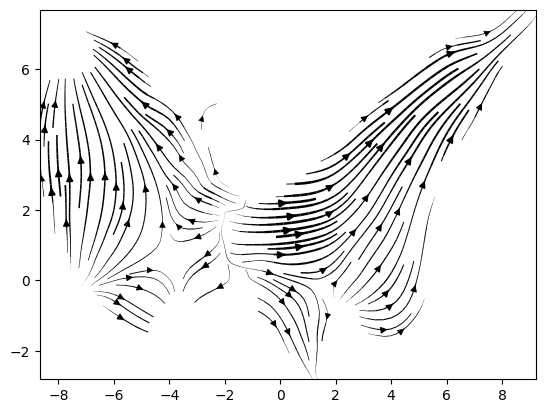

In [12]:
scv.tl.velocity_graph(DV_result)

AttributeError: can't set attribute

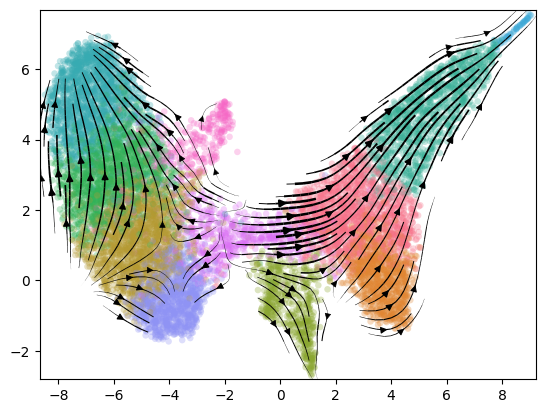

In [15]:
scv.pl.velocity_embedding_stream(DV_result, 
                             show=False, 
                             color = 'cell_type', 
                             title = 'DeepVelo',
                             fontsize = 25,
                            legend_fontsize = 15)# plt.savefig(fig_outdir+'DeepVelo_results.png', dpi = 600, transparent=True)
# plt.savefig(fig_outdir+'DeepVelo_results.svg', dpi = 600, transparent=True)

In [16]:
# write results 
DV_result.write(model_outdir+'DeepVelo_result.h5ad')